In [1]:
# import packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, auc # different metrics 
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor # RF model
from sklearn.tree import plot_tree # function to visualize a decision tree

In [2]:
# import data
data = pd.read_csv("surrland_soil_sr_landsc_clim.csv")


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print(data.columns.tolist())


['measurement.id', 'ma.id', 'study.id', 'control.id', 'latitude.decimal', 'longitude.decimal', 'country.new', 'treatment', 'crop.type.orig', 'crop.type.orig.grouped.small', 'crop.type.orig.grouped.big', 'poll.dependent', 'lrr', 'lrr.vi', 'temp.avg.1970.2000', 'prec.avg.1970.2000', 'nat.hab.1000', 'nat.hab.2500', 'nat.hab.5000', 'nat.hab.edgelength.1000', 'nat.hab.edgelength.2500', 'nat.hab.edgelength.5000', 'nat.hab.peri.area.ratio.1000', 'nat.hab.peri.area.ratio.2500', 'nat.hab.peri.area.ratio.5000', 'nat.hab.wo.grass.1000', 'nat.hab.wo.grass.2500', 'nat.hab.wo.grass.5000', 'nat.hab.wo.grass.edgelength.1000', 'nat.hab.wo.grass.edgelength.2500', 'nat.hab.wo.grass.edgelength.5000', 'nat.hab.wo.grass.peri.area.ratio.1000', 'nat.hab.wo.grass.peri.area.ratio.2500', 'nat.hab.wo.grass.peri.area.ratio.5000', 'cropland.1000', 'cropland.2500', 'cropland.5000', 'crop.peri.area.ratio.1000', 'crop.peri.area.ratio.2500', 'crop.peri.area.ratio.5000', 'crop.edgelength.1000', 'crop.edgelength.2500', '

In [4]:
data.isna().sum()

measurement.id                             0
ma.id                                      0
study.id                                   0
control.id                                 0
latitude.decimal                           0
longitude.decimal                          0
country.new                                0
treatment                                  0
crop.type.orig                             0
crop.type.orig.grouped.small               0
crop.type.orig.grouped.big                 0
poll.dependent                             0
lrr                                        0
lrr.vi                                   784
temp.avg.1970.2000                         0
prec.avg.1970.2000                         0
nat.hab.1000                               0
nat.hab.2500                               0
nat.hab.5000                               0
nat.hab.edgelength.1000                    0
nat.hab.edgelength.2500                    0
nat.hab.edgelength.5000                    0
nat.hab.pe

In [5]:
data1 = data.drop(['measurement.id', 'ma.id', 'study.id', 'control.id','lrr.vi'], axis = 1) # since we dont need this variables for prediction 
data1 = data1.drop(['fieldsize.centre', "soiltexture.centre",'country.new', 'treatment', 'crop.type.orig', 'crop.type.orig.grouped.small', 'crop.type.orig.grouped.big'], axis = 1) # drop categorical variables


In [6]:
data2 = data1.fillna(data1.mean())

In [7]:
data2.isna().sum()

latitude.decimal                         0
longitude.decimal                        0
poll.dependent                           0
lrr                                      0
temp.avg.1970.2000                       0
prec.avg.1970.2000                       0
nat.hab.1000                             0
nat.hab.2500                             0
nat.hab.5000                             0
nat.hab.edgelength.1000                  0
nat.hab.edgelength.2500                  0
nat.hab.edgelength.5000                  0
nat.hab.peri.area.ratio.1000             0
nat.hab.peri.area.ratio.2500             0
nat.hab.peri.area.ratio.5000             0
nat.hab.wo.grass.1000                    0
nat.hab.wo.grass.2500                    0
nat.hab.wo.grass.5000                    0
nat.hab.wo.grass.edgelength.1000         0
nat.hab.wo.grass.edgelength.2500         0
nat.hab.wo.grass.edgelength.5000         0
nat.hab.wo.grass.peri.area.ratio.1000    0
nat.hab.wo.grass.peri.area.ratio.2500    0
nat.hab.wo.

In [8]:
mask_poll0 = data2['poll.dependent'] == 0 # save the mask as object mask_poll0
mask_poll1 = data2['poll.dependent'] == 1 # save the mask as object mask_poll1
mask_poll0.sum() , mask_poll1.sum() # total number of pollinated and not pollinated (= number of Trues in each mask) 


(1281, 103)

In [9]:
# let's separate pollinated and not pollinated into two different dataframes
notpollinated = data2[mask_poll0]
pollinated = data2[mask_poll1]
notpollinated = notpollinated.sample(n = 103)
# final DataFrame with balanced pollinated and not pollinated, no missing values
data_cured = pd.concat([notpollinated, pollinated]) # pollinated and not pollinated are concatenated (row-wise) into DataFrame "data_cured" 

In [10]:
# Let's shuffle the DataFrame
data_cured = data_cured.sample(frac = 1) # frac = fraction of rows to be shuffled (or "sampled"). Here, 1 = 100% of samples (rows)

In [11]:
# the target vector will be the column "poll.dependent"
X = data_cured.drop(['poll.dependent'], axis = 1) # features are all columns except the target column
y = data_cured['poll.dependent'] # classes (=pollinated and not pollinated)

# we only use random_state to be able to split again X and y to generate precisely the same samples
# in X_train, y_train, etc.  Note that the function train_test_split() shuffles all rows of the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y) # stratify: get balanced subsets!

In [12]:
# Let's preprocess the features
scaler = StandardScaler()
scaler.fit(X_train) #mean and std of each feature of X_train are stored inside object "scaler"
X_train_s = scaler.transform(X_train) # convert X_train into zero mean and unit variance
X_test_s = scaler.transform(X_test) # convert X_test into zero mean and unit variance

In [13]:
rf = RandomForestClassifier() # create the model (with 100 trees by default)
rf.fit(X_train_s, y_train) # train the model (optimize splitting parameters for all (100) trees)

pred = rf.predict(X_test_s) # perform predictions

acc = rf.score(X_test_s, y_test) # number of correct classifications / total number of classifications

print(f'accuracy: {acc*100:.2f}%')

accuracy: 50.00%


In [14]:
report = classification_report(y_test, pred) 
print(report) # without the 'stratify' parameter used during dataset splitting, the 'support' below would be different for both classes

              precision    recall  f1-score   support

           0       0.50      0.52      0.51        21
           1       0.50      0.48      0.49        21

    accuracy                           0.50        42
   macro avg       0.50      0.50      0.50        42
weighted avg       0.50      0.50      0.50        42



In [15]:
# check which features are more important
feature_names = X.columns # ".columns" attribute of DataFrame object X has the names of all columns
importances = rf.feature_importances_ # get feature importances from the trained model 
# (impurity is computed as the mean and standard deviation of accumulation of the impurity decrease within each decision tree)

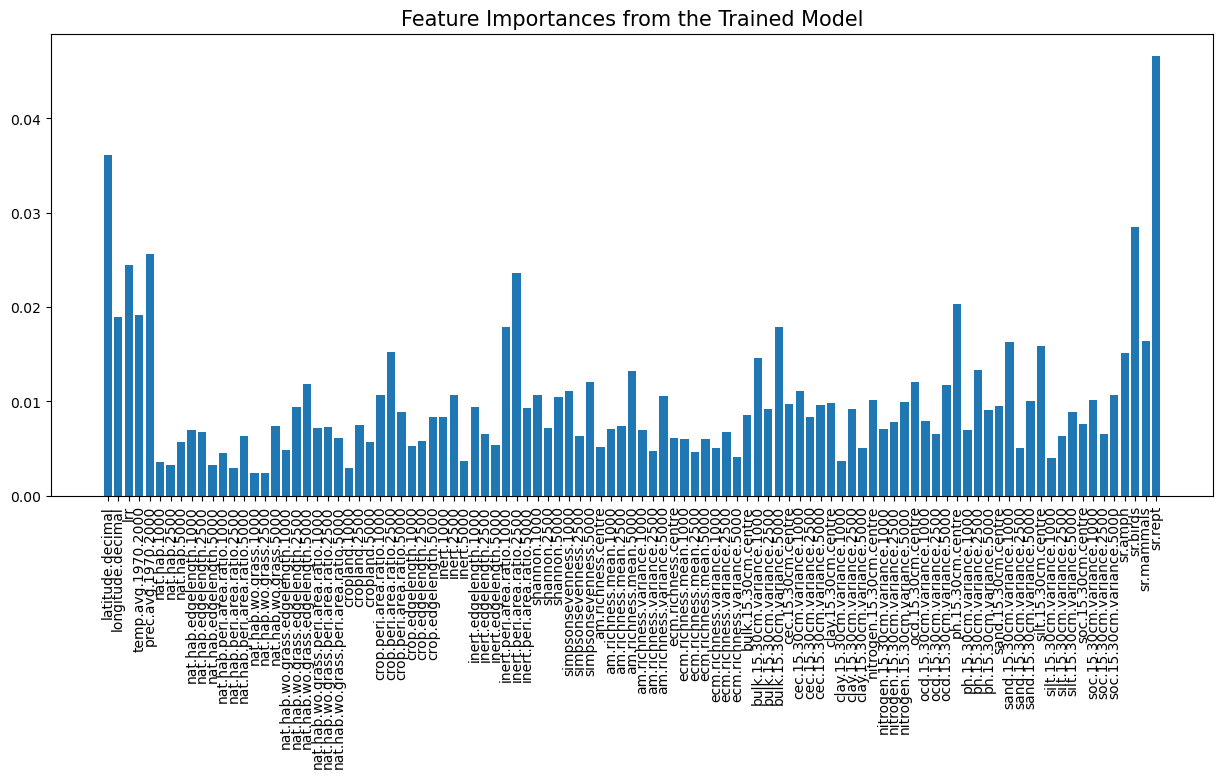

In [16]:
plt.figure(figsize=(15, 6))   # set figure size BEFORE plotting
plt.bar(feature_names, importances)
plt.xticks(rotation=90)
plt.title("Feature Importances from the Trained Model", fontsize=15)
plt.savefig('20251201_importance_poll_all_columns.jpeg', dpi=600) # uncomment this line to save your tree

In [17]:
# Let's decrease the maximum depth of the tree to facilitate visualization:
rf = RandomForestClassifier(max_depth=3)
rf.fit(X_train_s, y_train)

RandomForestClassifier(max_depth=3)

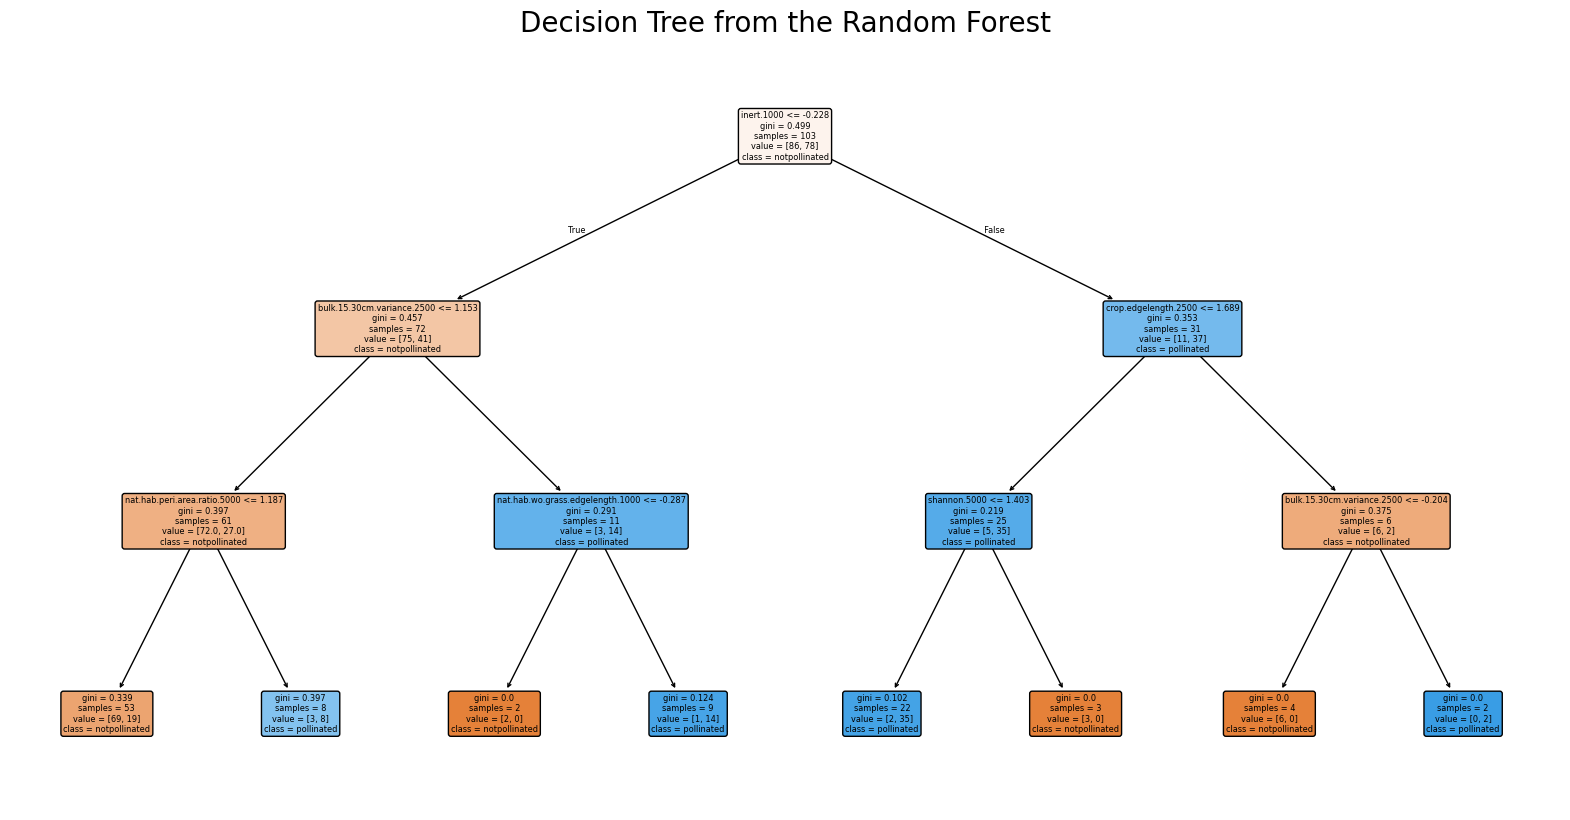

In [18]:
tree = rf.estimators_[0] # Let's visualize the first tree

plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=feature_names,  # List of your feature names
    class_names=['notpollinated', 'pollinated'],      # List of your class labels
    filled=True,
    rounded=True
)
plt.title("Decision Tree from the Random Forest", fontsize=20);
plt.savefig('20251201_poll_all_columns.jpeg', dpi=600) # uncomment this line to save your tree